# 06. Độ nhạy phân hoạch, kết quả Final Test đã khóa và tổng kết RQ1–RQ4

**Mục tiêu:** kiểm tra độ bền vững của năm cấu hình trên 10 phân hoạch Core, đối chiếu kiểm định ghép cặp và diễn giải lần chấm Final Test đã hoàn tất.

**Final Test đã được chấm một lần cho năm cấu hình khóa.** Notebook chỉ đọc `xgb_final_test_summary.csv` và manifest; không fit classifier, không đọc raw/split Test, không gọi script 08, không chỉnh ngưỡng hoặc chọn lại mô hình. Các hình ma trận nhầm lẫn được dựng từ số đếm đã lưu.

Nguồn SHAP duy nhất có chi tiết biến là global importance **Default XGBoost trên Reference**, qua 5 fold. Chưa có SHAP trên Final Test hoặc bảng importance chi tiết của bốn cấu hình tối ưu.


## 1. Kiểm tra bằng chứng và giao thức độ nhạy


In [9]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / 'configs' / 'data.yaml').is_file()), None)
if project_root is None:
    raise FileNotFoundError('Không tìm thấy thư mục dự án chứa configs/data.yaml.')
sys.path.insert(0, str(project_root / 'src'))
from creditrisk import visualization as viz
viz.set_scientific_theme()

tables = project_root / 'artifacts' / 'tables'
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

def read_table(name, required=()):
    path = tables / name
    if not path.is_file():
        raise FileNotFoundError(f'Thiếu artifact: {path}. Cần cung cấp kết quả đã lưu; notebook không chạy lại thực nghiệm.')
    frame = pd.read_csv(path)
    missing = set(required) - set(frame.columns)
    if missing:
        raise ValueError(f'{name} thiếu cột {sorted(missing)}')
    return frame

def show_figure(figure):
    display(figure)
    plt.close(figure)

with (project_root / 'configs' / 'data.yaml').open() as stream:
    data_config = yaml.safe_load(stream)
print('Chế độ phân tích artifact: không nạp dữ liệu tín dụng, không huấn luyện lại, không chấm lại Final Test.')


Chế độ phân tích artifact: không nạp dữ liệu tín dụng, không huấn luyện lại, không chấm lại Final Test.


In [10]:
repeats = read_table('xgb_sensitivity_repeats.csv', ['seed', 'candidate', 'roc_auc_cv', 'shap_stability', 'top_5_jaccard'])
summary = read_table('xgb_sensitivity_summary.csv')
paired_saved = read_table('xgb_sensitivity_paired.csv')
sensitivity_manifest = json.loads((tables / 'xgb_sensitivity_manifest.json').read_text())
with (project_root / 'configs' / 'sensitivity.yaml').open() as stream:
    sensitivity_config = yaml.safe_load(stream)
assert sensitivity_manifest['status'] == 'complete'
assert sensitivity_manifest['final_test_evaluated'] is False
assert set(repeats['seed']) == set(sensitivity_config['cv_seeds'])
assert not repeats.duplicated(['seed', 'candidate']).any()
assert repeats.groupby('seed')['folds_sha256'].nunique().eq(1).all()
assert repeats.groupby('candidate')['candidate_params_sha256'].nunique().eq(1).all()
assert repeats.groupby('candidate')['seed'].nunique().eq(len(sensitivity_config['cv_seeds'])).all()
assert set(repeats['candidate']) == set(sensitivity_config['candidate_trials'])
display(summary[['candidate', 'n_seeds', 'roc_auc_cv_mean', 'roc_auc_cv_std',
                 'shap_stability_mean', 'shap_stability_std', 'top_5_jaccard_mean', 'top_5_jaccard_std']])
print(f"{len(repeats)} đánh giá = {repeats['candidate'].nunique()} cấu hình × {repeats['seed'].nunique()} seed; "
      f"{sensitivity_manifest['completed_model_fits']} mô hình fold đã chạy trước đó.")


,candidate,n_seeds,roc_auc_cv_mean,roc_auc_cv_std,shap_stability_mean,shap_stability_std,top_5_jaccard_mean,top_5_jaccard_std
0,pareto_auc,10,0.787594,0.000682,0.933913,0.015876,0.782857,0.092954
1,pareto_balanced,10,0.787178,0.000542,0.947777,0.010718,0.699524,0.037219
2,pareto_stability,10,0.776891,0.000393,0.972586,0.002856,0.873333,0.095219
3,tpe_best,10,0.787643,0.000585,0.911472,0.017231,0.767619,0.047562
4,xgb_default,10,0.774809,0.001354,0.837589,0.039689,0.790000,0.047258


50 đánh giá = 5 cấu hình × 10 seed; 250 mô hình fold đã chạy trước đó.


## 2. Phân phối độ nhạy và chênh lệch ghép cặp

Chỉ thay đổi seed phân hoạch Core 101–110; seed mô hình 42, siêu tham số và Reference giữ nguyên. Mỗi điểm là một đánh giá 5-fold trên toàn Core, không phải một fold đơn lẻ.

Boxplot mô tả dao động theo phân hoạch của cùng dữ liệu. Đường nối theo seed và biểu đồ chênh lệch dùng cặp cùng phân hoạch để loại bỏ một phần dao động chung. `*_std` trong bảng summary dùng `ddof=0`; độ lệch chuẩn và CI chẩn đoán của chênh lệch ở phần kiểm định dùng `ddof=1`.


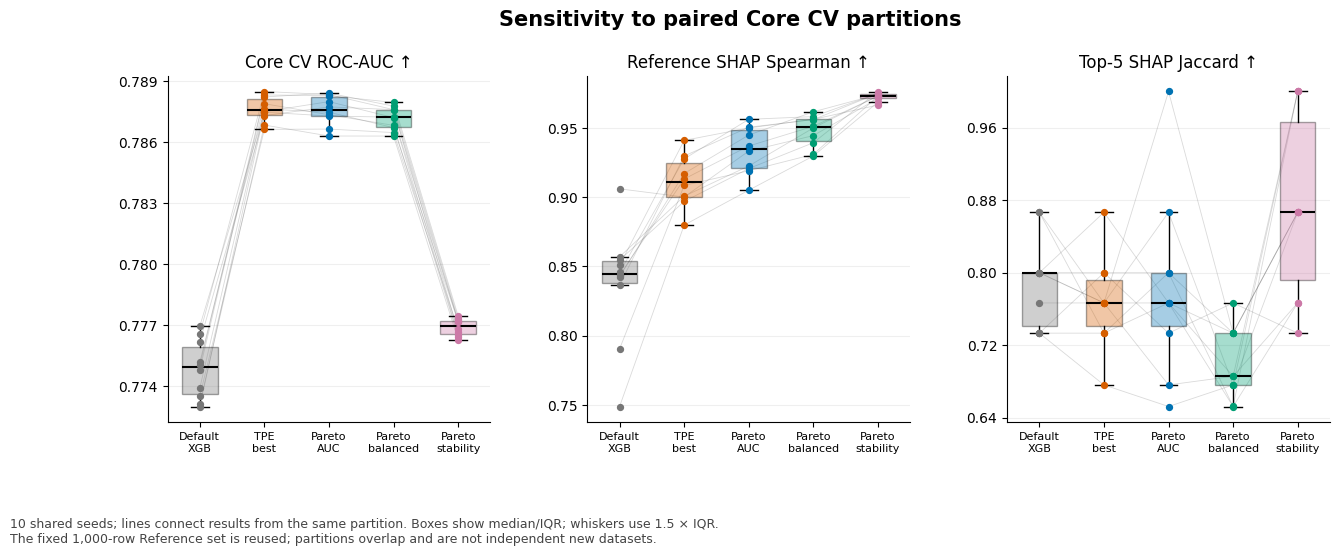

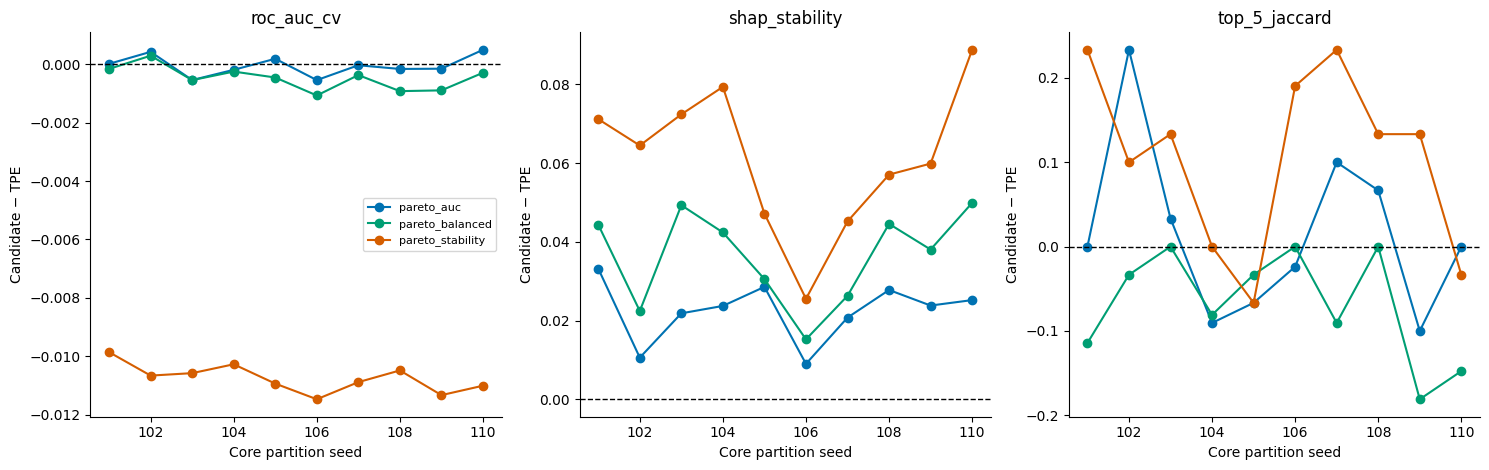

In [11]:
show_figure(viz.plot_sensitivity_analysis(repeats))
metrics = ['roc_auc_cv', 'shap_stability', 'top_5_jaccard']
pareto_candidates = ['pareto_auc', 'pareto_balanced', 'pareto_stability']
paired_tables = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
colors = ['#0072B2', '#009E73', '#D55E00']
for ax, metric in zip(axes, metrics):
    wide = repeats.pivot(index='seed', columns='candidate', values=metric).sort_index()
    differences = wide[pareto_candidates].subtract(wide['tpe_best'], axis=0)
    paired_tables[metric] = differences
    for candidate, color in zip(pareto_candidates, colors):
        ax.plot(differences.index, differences[candidate], marker='o', label=candidate, color=color)
        recorded = paired_saved.loc[(paired_saved['candidate'] == candidate) &
                                    paired_saved['comparator'].eq('tpe_best')].set_index('seed')
        assert np.allclose(differences[candidate], recorded[f'delta_{metric}'].reindex(differences.index))
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set(title=metric, xlabel='Core partition seed', ylabel='Candidate − TPE')
axes[0].legend(fontsize=8)
fig.tight_layout()
show_figure(fig)


## 3. Kiểm định ghép cặp: bằng chứng thăm dò có điều chỉnh đa kiểm định

Đặt $d_s=f(\theta,s)-f(\theta_{TPE},s)$ cho cùng seed. Báo cáo kiểm định **hai phía**: Wilcoxon signed-rank (chính) và paired t-test (phân tích nhạy theo giả định). Sai khác được làm tròn đến 12 chữ số khi đếm dấu và dùng Wilcoxon để coi nhiễu máy ở 10^-16 là hòa. Cả hai kiểm tra chênh lệch bằng 0 theo mô hình của chúng; không tự động kiểm tra tương đương thực tiễn.

Áp dụng **Holm cho chín so sánh** (3 nghiệm Pareto × 3 chỉ số AUC/Spearman/Jaccard), **riêng cho từng loại kiểm định**. Đây là hai họ kết quả của cùng một phân tích, không chọn kiểm định có p nhỏ hơn. CI t 95% của chênh lệch chỉ là chẩn đoán theo giả định, chưa hiệu chỉnh đa so sánh.

**Giới hạn suy luận:** các phân hoạch tái dùng cùng 23.000 khách hàng, training fold chồng lấn và Reference cố định; các đánh giá không phải mười dataset độc lập. t-test cần chênh lệch gần chuẩn/độc lập; Wilcoxon cần phân phối chênh lệch đối xứng/độc lập và khó đánh giá ở $n=10$. Vì vậy p-values và CI dưới đây là **thăm dò có điều kiện trên Core này**, không chứng minh ưu thế ở quần thể mới và không thay thế kiểm chứng ngoài dataset. Không coi “p ≥ 0,05” là bằng nhau, không dùng kết quả để chọn lại cấu hình.


In [12]:
from scipy import stats

def holm_adjust(p_values):
    values = np.asarray(p_values, dtype=float)
    if not np.isfinite(values).all():
        raise ValueError('p-values phải hữu hạn.')
    order = np.argsort(values, kind='stable')
    adjusted_sorted = np.minimum(1, np.maximum.accumulate((len(values) - np.arange(len(values))) * values[order]))
    adjusted = np.empty_like(values)
    adjusted[order] = adjusted_sorted
    return adjusted

test_rows = []
for metric in metrics:
    for candidate in pareto_candidates:
        differences = paired_tables[metric][candidate].to_numpy()
        n = len(differences)
        sd = differences.std(ddof=1)
        mean = differences.mean()
        radius = stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n)
        p_t = float(stats.ttest_1samp(differences, popmean=0).pvalue) if sd else (1.0 if mean == 0 else 0.0)
        rounded = np.round(differences, 12)
        p_w = float(stats.wilcoxon(rounded, alternative='two-sided', method='auto').pvalue) if np.any(rounded != 0) else 1.0
        test_rows.append({'candidate': candidate, 'metric': metric, 'n_pairs': n,
                          'mean_difference': mean, 'sample_SD': sd, 'diagnostic_CI_low': mean - radius,
                          'diagnostic_CI_high': mean + radius,
                          'positive_seeds': int((rounded > 0).sum()),
                          'negative_seeds': int((rounded < 0).sum()), 'equal_seeds': int((rounded == 0).sum()), 'p_t': p_t, 'p_wilcoxon': p_w})
tests = pd.DataFrame(test_rows)
tests['p_t_Holm_9'] = holm_adjust(tests['p_t'])
tests['p_wilcoxon_Holm_9'] = holm_adjust(tests['p_wilcoxon'])
display(tests.style.format({column: '{:.6f}' for column in tests.select_dtypes('float').columns}))
stability_tests = tests.loc[tests['metric'].eq('shap_stability')]
display(Markdown('**Quan sát độ nhạy:** cả ba đại diện Pareto có Δ Spearman dương ở mọi seed so với TPE. '
                 'Nghiệm Balanced có AUC hơi thấp hơn và Jaccard top-5 thấp hơn TPE; '
                 'do đó “ổn định hơn” trong kết luận RQ3 phải được hiểu theo mục tiêu Spearman đã khóa. '
                 'Không diễn giải các kiểm định này thành khẳng định nhân quả hoặc bảo đảm tổng quát hóa.'))


,candidate,metric,n_pairs,mean_difference,sample_SD,diagnostic_CI_low,diagnostic_CI_high,positive_seeds,negative_seeds,equal_seeds,p_t,p_wilcoxon,p_t_Holm_9,p_wilcoxon_Holm_9
0,pareto_auc,roc_auc_cv,10,-0.000049,0.000351,-0.000300,0.000203,4,6,0,0.671560,0.556641,1.000000,1.000000
1,pareto_balanced,roc_auc_cv,10,-0.000465,0.000411,-0.000759,-0.000171,1,9,0,0.005909,0.013672,0.029543,0.068359
2,pareto_stability,roc_auc_cv,10,-0.010752,0.000484,-0.011098,-0.010406,0,10,0,0.000000,0.001953,0.000000,0.017578
3,pareto_auc,shap_stability,10,0.022441,0.007584,0.017016,0.027866,10,0,0,0.000006,0.001953,0.000037,0.017578
4,pareto_balanced,shap_stability,10,0.036304,0.012010,0.027713,0.044896,10,0,0,0.000005,0.001953,0.000036,0.017578
5,pareto_stability,shap_stability,10,0.061113,0.018477,0.047895,0.074331,10,0,0,0.000002,0.001953,0.000020,0.017578
6,pareto_auc,top_5_jaccard,10,0.015238,0.100485,-0.056645,0.087121,4,4,2,0.642990,0.812500,1.000000,1.000000
7,pareto_balanced,top_5_jaccard,10,-0.068095,0.065139,-0.114693,-0.021497,0,7,3,0.009145,0.015625,0.036581,0.068359
8,pareto_stability,top_5_jaccard,10,0.105714,0.106617,0.029445,0.181983,7,2,1,0.012014,0.019531,0.036581,0.068359


**Quan sát độ nhạy:** cả ba đại diện Pareto có Δ Spearman dương ở mọi seed so với TPE. Nghiệm Balanced có AUC hơi thấp hơn và Jaccard top-5 thấp hơn TPE; do đó “ổn định hơn” trong kết luận RQ3 phải được hiểu theo mục tiêu Spearman đã khóa. Không diễn giải các kiểm định này thành khẳng định nhân quả hoặc bảo đảm tổng quát hóa.

## 4. Final Test: kiểm tra tính toàn vẹn, rồi đọc kết quả đã lưu

Manifest ghi nhận đúng năm cấu hình, năm lần chấm mô hình trong **một giai đoạn Final Test duy nhất**, 24.000 mẫu Development để fit cuối và 6.000 mẫu Test. Không có SHAP trên Test; Test không dùng để chọn cấu hình hoặc ngưỡng. So sánh hash của summary và của tham số giúp tránh đọc nhầm kết quả khác giao thức.


In [13]:
import hashlib

final_path = tables / 'xgb_final_test_summary.csv'
final_summary = read_table(final_path.name, ['candidate', 'roc_auc', 'tn', 'fp', 'fn', 'tp'])
final_manifest = json.loads((tables / 'xgb_final_test_manifest.json').read_text())
assert final_manifest['status'] == 'complete'
assert final_manifest['final_test_evaluated'] is True
assert final_manifest['test_used_for_selection'] is False
assert final_manifest['shap_computed_on_test'] is False
assert hashlib.sha256(final_path.read_bytes()).hexdigest() == final_manifest['summary_sha256']
assert set(final_summary['candidate']) == set(final_manifest['candidate_names'])
assert len(final_summary) == final_manifest['completed_test_evaluations'] == 5
assert final_summary['candidate'].is_unique
assert final_summary['n_test'].eq(6000).all() and final_summary['n_development'].eq(24000).all()
assert final_summary['threshold'].eq(final_manifest['threshold']).all()
assert final_summary[['tn', 'fp', 'fn', 'tp']].sum(axis=1).eq(final_summary['n_test']).all()
for row in final_summary.itertuples():
    assert row.candidate_params_sha256 == final_manifest['candidate_params_sha256'][row.candidate]
    assert row.candidate_params_sha256 == sensitivity_manifest['candidate_sources'][row.candidate].get('candidate_params_sha256',
                                          repeats.loc[repeats['candidate'].eq(row.candidate), 'candidate_params_sha256'].iloc[0])
display(final_summary[['candidate', 'trial', 'threshold', 'roc_auc', 'average_precision', 'f1',
                       'precision', 'recall', 'balanced_accuracy', 'brier_score']].sort_values('roc_auc', ascending=False))
print('Summary hash, cấu hình khóa và các số đếm đều hợp lệ; không có lần chấm Test mới.')


,candidate,trial,threshold,roc_auc,average_precision,f1,precision,recall,balanced_accuracy,brier_score
2,pareto_balanced,61,0.500000,0.781791,0.559020,0.460857,0.664773,0.352675,0.651086,0.134622
3,tpe_best,50,0.500000,0.781011,0.558185,0.471735,0.667586,0.364732,0.656580,0.134681
0,pareto_auc,44,0.500000,0.779784,0.557473,0.464181,0.665260,0.356443,0.652756,0.134759
4,xgb_default,-1,0.500000,0.769664,0.539973,0.476834,0.663087,0.372268,0.659278,0.137585
1,pareto_stability,57,0.500000,0.768113,0.537826,0.248900,0.750000,0.149209,0.567543,0.144236


Summary hash, cấu hình khóa và các số đếm đều hợp lệ; không có lần chấm Test mới.


## 5. Ma trận nhầm lẫn, ngưỡng 0,5 và giới hạn ROC/PR

Ma trận gồm `[[TN, FP], [FN, TP]]`, nhãn thực ở hàng và nhãn dự đoán ở cột. Recall là $TP/(TP+FN)$; specificity là $TN/(TN+FP)$. Trong tài chính, bỏ sót nợ xấu (FN) và từ chối người tốt (FP) có chi phí khác nhau; ngưỡng 0,5 chỉ là giao thức đã khóa.

Chưa lưu `y_true`/`y_score` của lần chấm độc lập, nên **không thể vẽ ROC/PR thật** hoặc khoảng tin cậy bootstrap AUC từ bảng summary. Hình dưới trình bày chỉ số đã lưu và các ma trận thật. Không chấm lại Final Test để điền khoảng trống này. Điều chỉnh ngưỡng chỉ là đề xuất cho một quy trình Development mới, không thử trên Test hiện tại.


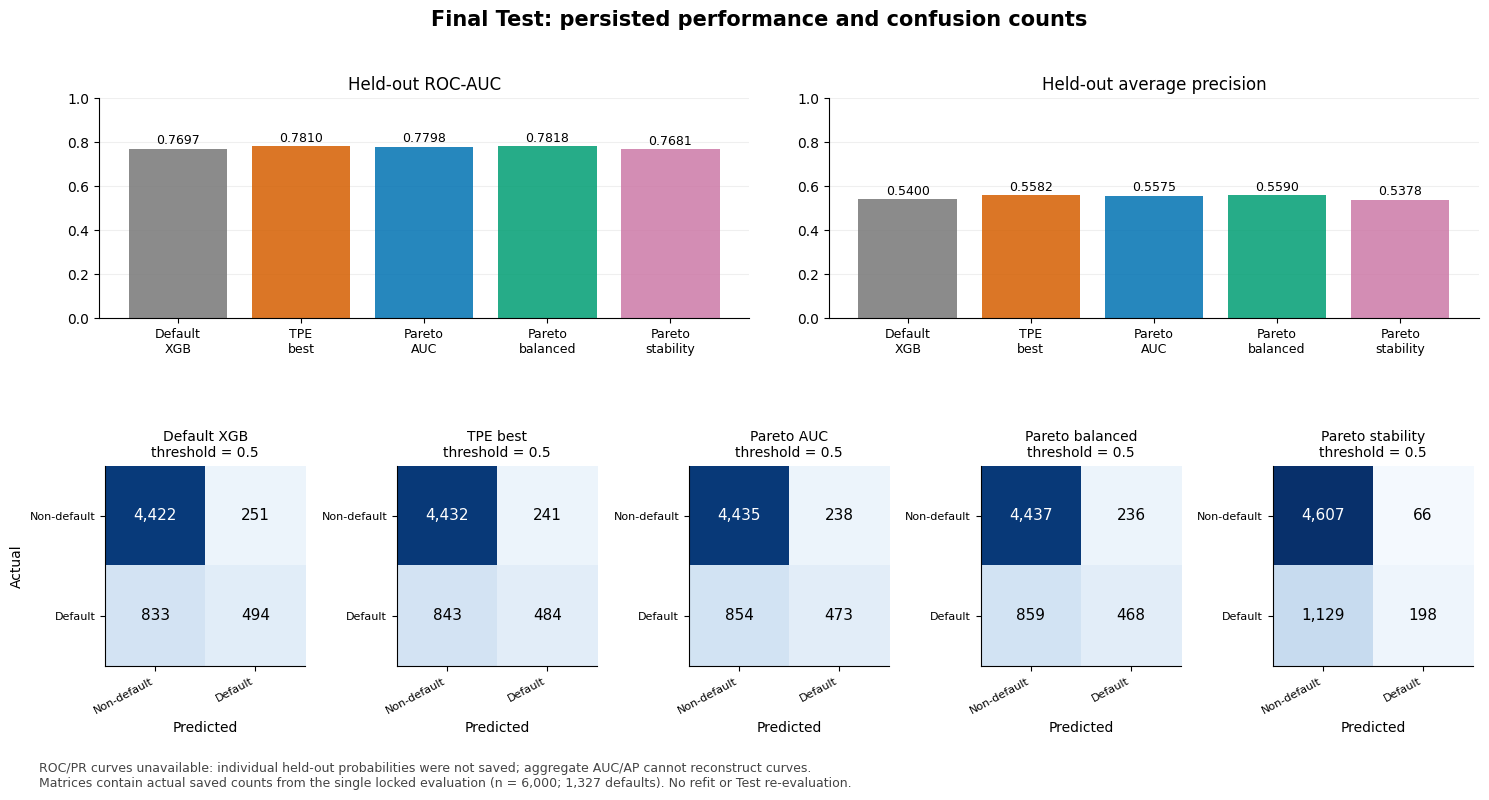

,candidate,tn,fp,fn,tp,n_test,recall_from_counts,specificity_from_counts,predicted_positive_fraction
0,pareto_auc,4435,238,854,473,6000,0.356443,0.949069,0.118500
1,pareto_stability,4607,66,1129,198,6000,0.149209,0.985876,0.044000
2,pareto_balanced,4437,236,859,468,6000,0.352675,0.949497,0.117333
3,tpe_best,4432,241,843,484,6000,0.364732,0.948427,0.120833
4,xgb_default,4422,251,833,494,6000,0.372268,0.946287,0.124167


In [14]:
show_figure(viz.plot_final_test_performance(final_summary))
diagnostics = final_summary[['candidate', 'tn', 'fp', 'fn', 'tp', 'n_test']].copy()
diagnostics['recall_from_counts'] = diagnostics['tp'] / (diagnostics['tp'] + diagnostics['fn'])
diagnostics['specificity_from_counts'] = diagnostics['tn'] / (diagnostics['tn'] + diagnostics['fp'])
diagnostics['predicted_positive_fraction'] = (diagnostics['tp'] + diagnostics['fp']) / diagnostics['n_test']
assert np.allclose(diagnostics['recall_from_counts'], final_summary['recall'])
assert np.allclose((diagnostics['recall_from_counts'] + diagnostics['specificity_from_counts']) / 2,
                   final_summary['balanced_accuracy'])
display(diagnostics)


## 6. SHAP trên Reference: importance toàn cục và biến động thứ hạng

Chỉ dùng `artifacts/shap/xgb_default_importance_by_fold.csv` nếu có. Bảng chứa mean $|\mathrm{SHAP}|$ của **23 biến gốc**, trên cùng Reference 1.000 mẫu, từ năm mô hình Default huấn luyện trên năm tập train Core khác nhau; đơn vị raw log-odds margin. Trung bình và độ lệch chuẩn được tính qua các mô hình fold.

Không có SHAP từng khách hàng nên không vẽ beeswarm, dấu tác động hoặc phân tích cá thể. Không có bảng chi tiết của cấu hình tối ưu nên chưa kết luận các cấu hình đó luôn giữ cùng top-10. Quan sát PAY_0, LIMIT_BAL, BILL_AMT1,... chỉ thuộc Default/Reference và phải đọc từ artifact.


,mean_abs_SHAP,fold_SD_ddof0,mean_rank
PAY_0,0.542911,0.005725,1.000000
LIMIT_BAL,0.235367,0.006880,2.000000
BILL_AMT1,0.171337,0.015031,3.200000
PAY_AMT2,0.154387,0.017304,4.200000
PAY_AMT1,0.137604,0.015504,4.800000
PAY_AMT3,0.117772,0.015472,6.200000
BILL_AMT3,0.093889,0.017655,9.400000
PAY_AMT5,0.088096,0.009846,11.000000
BILL_AMT6,0.087881,0.005492,10.200000
PAY_2,0.085005,0.009375,11.400000


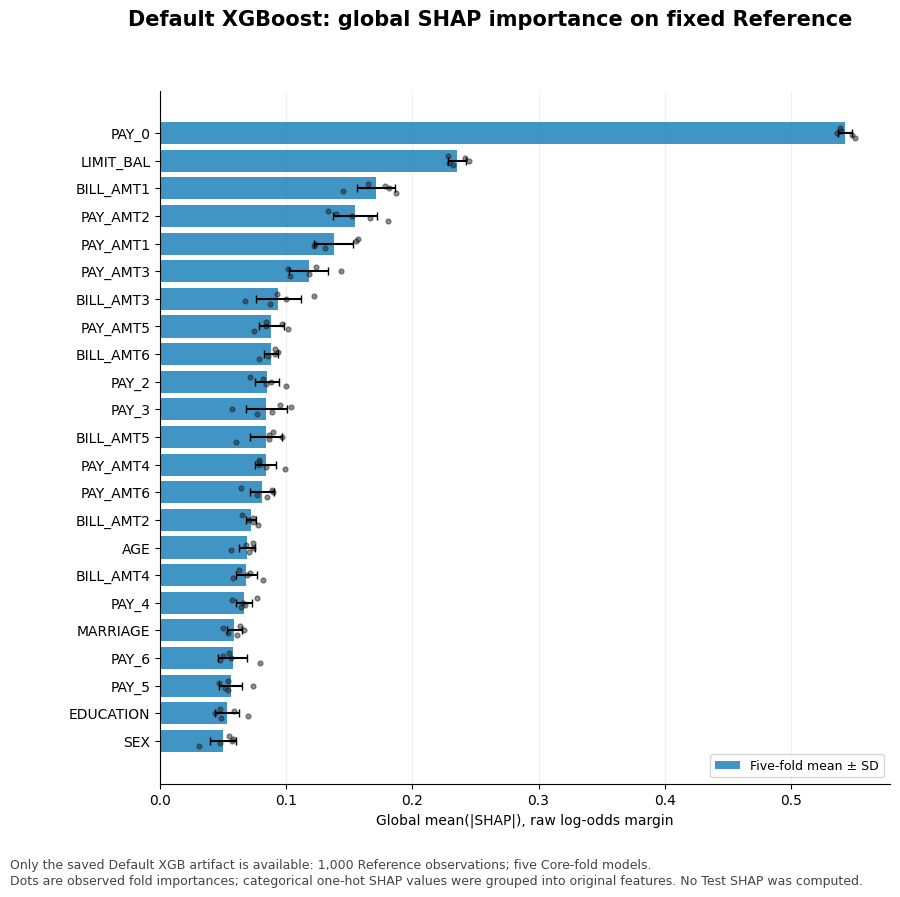

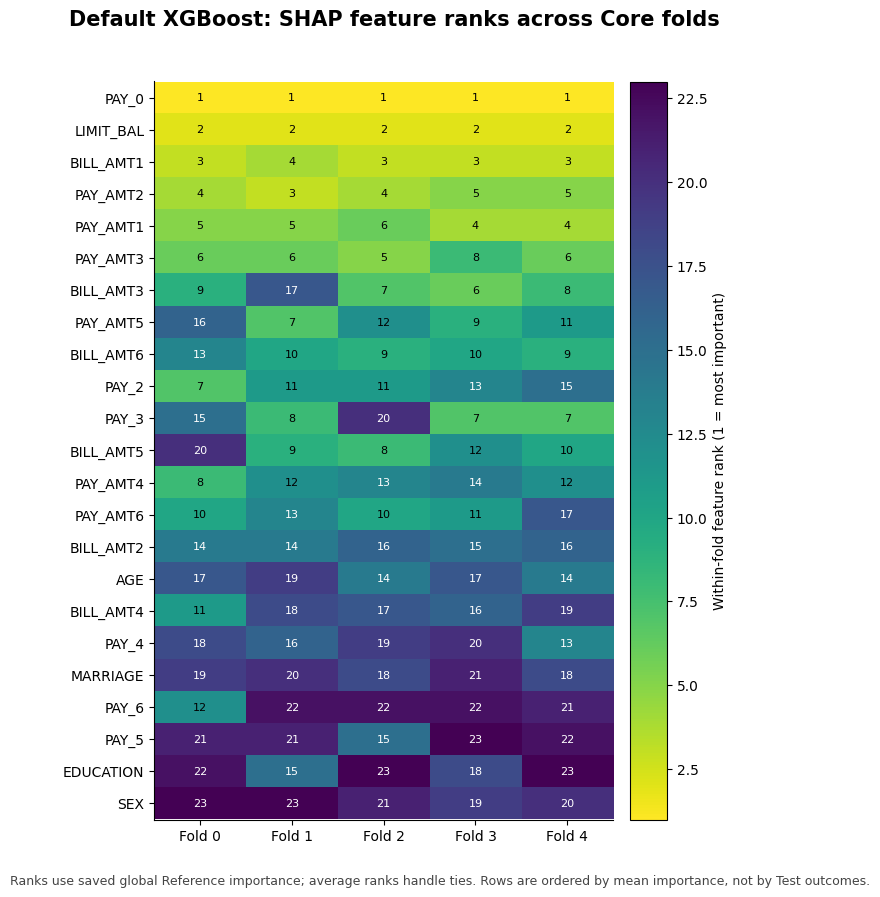

In [15]:
shap_path = project_root / 'artifacts' / 'shap' / 'xgb_default_importance_by_fold.csv'
if shap_path.is_file():
    importance_by_fold = pd.read_csv(shap_path).rename(columns=lambda name: name.strip())
    feature_values = importance_by_fold.drop(columns=['fold'])
    assert len(feature_values) == 5 and feature_values.shape[1] == 23
    assert np.isfinite(feature_values.to_numpy()).all() and feature_values.ge(0).all().all()
    top10 = pd.DataFrame({'mean_abs_SHAP': feature_values.mean(),
                          'fold_SD_ddof0': feature_values.std(ddof=0),
                          'mean_rank': feature_values.rank(axis=1, ascending=False).mean()})
    display(top10.sort_values('mean_abs_SHAP', ascending=False).head(10))
    show_figure(viz.plot_global_shap_importance(importance_by_fold))
    show_figure(viz.plot_shap_rank_variation(importance_by_fold))
else:
    display(Markdown('**Thiếu artifact SHAP Reference chi tiết.** Phần này không dựng số liệu hoặc huấn luyện lại. '
                     'Các chỉ số stability tổng hợp vẫn đọc được trong bảng sensitivity.'))


## 7. Tổng hợp Development → Final Test

Giữ trục stability là **Development/Reference**, không gọi đó là stability trên Final Test. CV và Test được đánh giá trên dữ liệu và tập huấn luyện khác nhau, nên chênh lệch AUC là mô tả tổng quát hóa, không phải phép kiểm định ghép cặp tương đương.


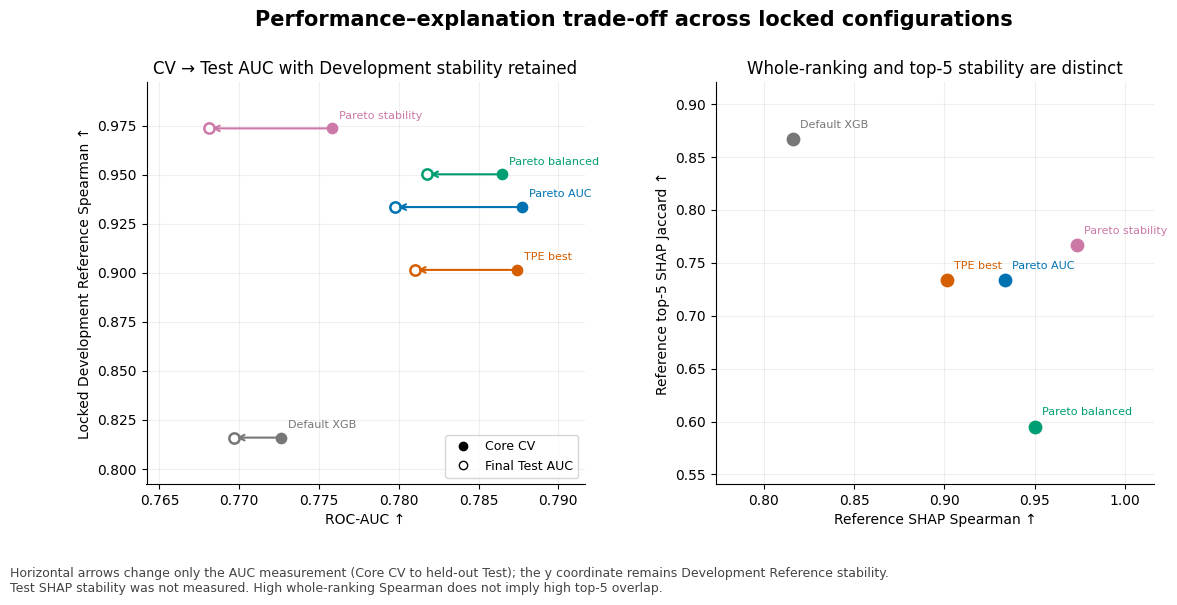

,candidate,roc_auc_cv,shap_stability,top_5_jaccard,roc_auc,Test_AUC_minus_original_CV_AUC,recall,brier_score
0,xgb_default,0.772620,0.816008,0.866667,0.769664,-0.002956,0.372268,0.137585
1,tpe_best,0.787436,0.901482,0.733333,0.781011,-0.006425,0.364732,0.134681
2,pareto_auc,0.787721,0.933498,0.733333,0.779784,-0.007937,0.356443,0.134759
3,pareto_stability,0.775843,0.973594,0.766667,0.768113,-0.007730,0.149209,0.144236
4,pareto_balanced,0.786497,0.950198,0.595238,0.781791,-0.004706,0.352675,0.134622


Balanced có AUC Test **0.781791**, cao nhất trong năm cấu hình đã khóa. Đây là kết quả mô tả trên một Test; không dùng thứ hạng này để chọn lại hoặc tuyên bố superiority thống kê.

In [16]:
comparison = read_table('xgb_pareto_comparison.csv')
show_figure(viz.plot_summary_tradeoff_landscape(comparison, final_summary))
role_to_candidate = {'default': 'xgb_default', 'auc_best_tpe': 'tpe_best',
                     'auc': 'pareto_auc', 'stability': 'pareto_stability', 'balanced': 'pareto_balanced'}
landscape = comparison.assign(candidate=comparison['selection_role'].map(role_to_candidate))
landscape = landscape.merge(final_summary[['candidate', 'roc_auc', 'recall', 'brier_score']], on='candidate', validate='one_to_one')
landscape['Test_AUC_minus_original_CV_AUC'] = landscape['roc_auc'] - landscape['roc_auc_cv']
display(landscape[['candidate', 'roc_auc_cv', 'shap_stability', 'top_5_jaccard', 'roc_auc',
                   'Test_AUC_minus_original_CV_AUC', 'recall', 'brier_score']])
balanced_test = final_summary.set_index('candidate').loc['pareto_balanced']
display(Markdown(f"Balanced có AUC Test **{balanced_test['roc_auc']:.6f}**, cao nhất trong năm cấu hình đã khóa. "
                 "Đây là kết quả mô tả trên một Test; không dùng thứ hạng này để chọn lại hoặc tuyên bố superiority thống kê."))


## 8. Trả lời trực diện RQ1–RQ4 và hướng ứng dụng

| Câu hỏi | Bằng chứng và câu trả lời | Ranh giới kết luận |
|---|---|---|
| **RQ1** | Chín siêu tham số liên hệ với AUC/stability; bảng Spearman, phân bố và permutation importance của mô hình phụ ở Notebook 05 chỉ ra ảnh hưởng trong vùng đã khảo sát. | Không có thí nghiệm thay một tham số giữ tất cả phần còn lại; không kết luận nhân quả. |
| **RQ2** | TPE trial 50 tăng AUC/Spearman so với Default nhưng Jaccard top-5 giảm (0,7333 so với 0,8667). | Tối ưu AUC không bảo đảm ổn định tập biến quan trọng. |
| **RQ3** | NSGA-II tìm sáu nghiệm Pareto; Balanced trial 61 đổi khoảng 0,00094 AUC CV để tăng khoảng 0,04872 Spearman trên phân hoạch gốc. Độ nhạy xác nhận Δ Spearman dương qua cả 10 seed. | Balanced có Jaccard thấp hơn ở 7 seed và bằng TPE ở 3 seed (làm tròn sai khác đến 12 chữ số); p-values chỉ thăm dò trên cùng Core. |
| **RQ4** | XGBoost sau HPO vượt các cấu hình baseline đã chạy về AUC Core CV; baseline mạnh nhất là CatBoost. | Chưa tối ưu các baseline với ngân sách bằng nhau; không có Final Test cho sáu baseline. |

Trong ứng dụng tín dụng, Balanced là phương án tham khảo khi muốn AUC tốt và thứ hạng SHAP toàn cục bền vững. Nếu yêu cầu báo cáo top-5 ổn định, cần đặt Jaccard thành tiêu chí/ràng buộc rõ ràng trong một nghiên cứu mới. Ngưỡng quyết định và calibration cần được thiết kế trên Development theo cost-matrix, rồi kiểm chứng bằng dữ liệu mới hoặc Test mới đã khóa.

**Hạn chế và hướng Chương 4:** một dataset UCI năm 2005; phân hoạch ngẫu nhiên chưa kiểm chứng temporal drift; dữ liệu đặc trưng tương quan; TreeSHAP path-dependent; một seed sampler và ngân sách 64 trial; các phân hoạch sensitivity tái dùng Core; thiếu dự đoán/SHAP chi tiết cho một số hình. Nghiên cứu tiếp theo cần dataset ngoài, temporal validation, ngân sách HPO công bằng, uncertainty trên dữ liệu mới và giao thức lưu prediction/SHAP trước lần Test độc lập.

### Tự kiểm tra

1. Tại sao Spearman tăng nhưng Jaccard top-5 giảm vẫn là kết quả hợp lệ của hai mục tiêu?
2. Tại sao Wilcoxon và t-test ở đây chỉ được diễn giải thăm dò?
3. Vì sao không được chọn lại cấu hình sau khi thấy Balanced đứng đầu AUC Test?
